## Setup

In [1]:
!pip install opencv-python-headless matplotlib numpy scikit-image scipy -q

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from skimage import exposure
from scipy.ndimage import gaussian_filter
from numpy.fft import fft2, ifft2
import warnings
warnings.filterwarnings('ignore')

print('OpenCV version:', cv2.__version__)
print('NumPy version:', np.__version__)

OpenCV version: 5.0.0
NumPy version: 2.1.3


In [6]:
import os

print("Files in /content/:")
for f in os.listdir('/content'):
    if not f.startswith('.') and f != 'sample_data':
        print("  ", f)

filename = 'dark_image.jpeg'

assert os.path.exists(filename), \
    f"'{filename}' not found. Check the list above and edit the filename."
print(f"Ready to use: {filename}")

Files in /content/:
   dark_image.jpeg
Ready to use: dark_image.jpeg


In [7]:
img_bgr = cv2.imread(filename)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Optional: resize if too large
MAX_DIM = 1024
h, w = img_rgb.shape[:2]
if max(h, w) > MAX_DIM:
    scale = MAX_DIM / max(h, w)
    img_rgb = cv2.resize(img_rgb, (int(w*scale), int(h*scale)))
    print(f'Resized from {w}x{h} to {img_rgb.shape[1]}x{img_rgb.shape[0]}')

print('Shape:', img_rgb.shape)
print('Dtype:', img_rgb.dtype)

Resized from 2160x3840 to 576x1024
Shape: (1024, 576, 3)
Dtype: uint8


## Helper Functions

In [8]:
def show_images(images, titles, figsize=(18, 6)):
    """Display a list of images side by side."""
    n = len(images)
    plt.figure(figsize=figsize)
    for i, (im, title) in enumerate(zip(images, titles)):
        plt.subplot(1, n, i + 1)
        if im.ndim == 2:
            plt.imshow(im, cmap='gray')
        else:
            plt.imshow(im)
        plt.title(title, fontsize=12)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


def plot_histograms(images, titles, figsize=(18, 4)):
    """Plot grayscale histograms side by side."""
    n = len(images)
    plt.figure(figsize=figsize)
    for i, (im, title) in enumerate(zip(images, titles)):
        plt.subplot(1, n, i + 1)
        gray = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY) if im.ndim == 3 else im
        plt.hist(gray.ravel(), bins=256, range=[0, 256], color='steelblue')
        plt.title(f'Histogram: {title}')
        plt.xlim([0, 256])
        plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Enhancement Functions

Each function returns a new image (no in-place modification).

In [9]:
def histogram_equalization(image):
    """Global histogram equalization."""
    if image.ndim == 2:
        return cv2.equalizeHist(image)
    ycrcb = cv2.cvtColor(image, cv2.COLOR_RGB2YCrCb)
    ycrcb[:, :, 0] = cv2.equalizeHist(ycrcb[:, :, 0])
    return cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2RGB)


def clahe_enhance(image, clip_limit=2.0, tile_grid=(8, 8)):
    """Contrast Limited Adaptive Histogram Equalization."""
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    if image.ndim == 2:
        return clahe.apply(image)
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)


def gamma_correction(image, gamma=1.0):
    """gamma < 1 brightens; gamma > 1 darkens."""
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255
                      for i in np.arange(0, 256)]).astype('uint8')
    return cv2.LUT(image, table)


def adjust_brightness_contrast(image, alpha=1.0, beta=0):
    """alpha: contrast multiplier, beta: brightness offset."""
    return cv2.convertScaleAbs(image, alpha=alpha, beta=beta)


def sharpen_image(image):
    """3x3 sharpening kernel."""
    kernel = np.array([[ 0, -1,  0],
                       [-1,  5, -1],
                       [ 0, -1,  0]])
    return cv2.filter2D(image, -1, kernel)


def unsharp_mask(image, sigma=2.0, strength=1.5):
    """Subtract blurred version to enhance edges."""
    blurred = cv2.GaussianBlur(image, (0, 0), sigma)
    sharpened = cv2.addWeighted(image, 1 + strength, blurred, -strength, 0)
    return np.clip(sharpened, 0, 255).astype(np.uint8)


def denoise_image(image):
    """Non-local means denoising."""
    if image.ndim == 3:
        return cv2.fastNlMeansDenoisingColored(image, None, 10, 10, 7, 21)
    return cv2.fastNlMeansDenoising(image, None, 10, 7, 21)


def wiener_deblur(image, kernel_size=5, noise=0.01):
    """Wiener deconvolution (single-channel result)."""
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY) if image.ndim == 3 else image
    h, w = gray.shape
    kernel = np.ones((kernel_size, kernel_size)) / (kernel_size ** 2)
    psf = np.zeros_like(gray, dtype=np.float32)
    kh, kw = kernel.shape
    psf[:kh, :kw] = kernel
    psf = np.roll(psf, -kh // 2, axis=0)
    psf = np.roll(psf, -kw // 2, axis=1)
    psf_fft = fft2(psf)
    gray_fft = fft2(gray.astype(np.float32))
    result = np.real(ifft2(gray_fft * np.conj(psf_fft) /
                          (np.abs(psf_fft) ** 2 + noise)))
    return np.clip(result, 0, 255).astype(np.uint8)

## Apply All Techniques to the Uploaded Image

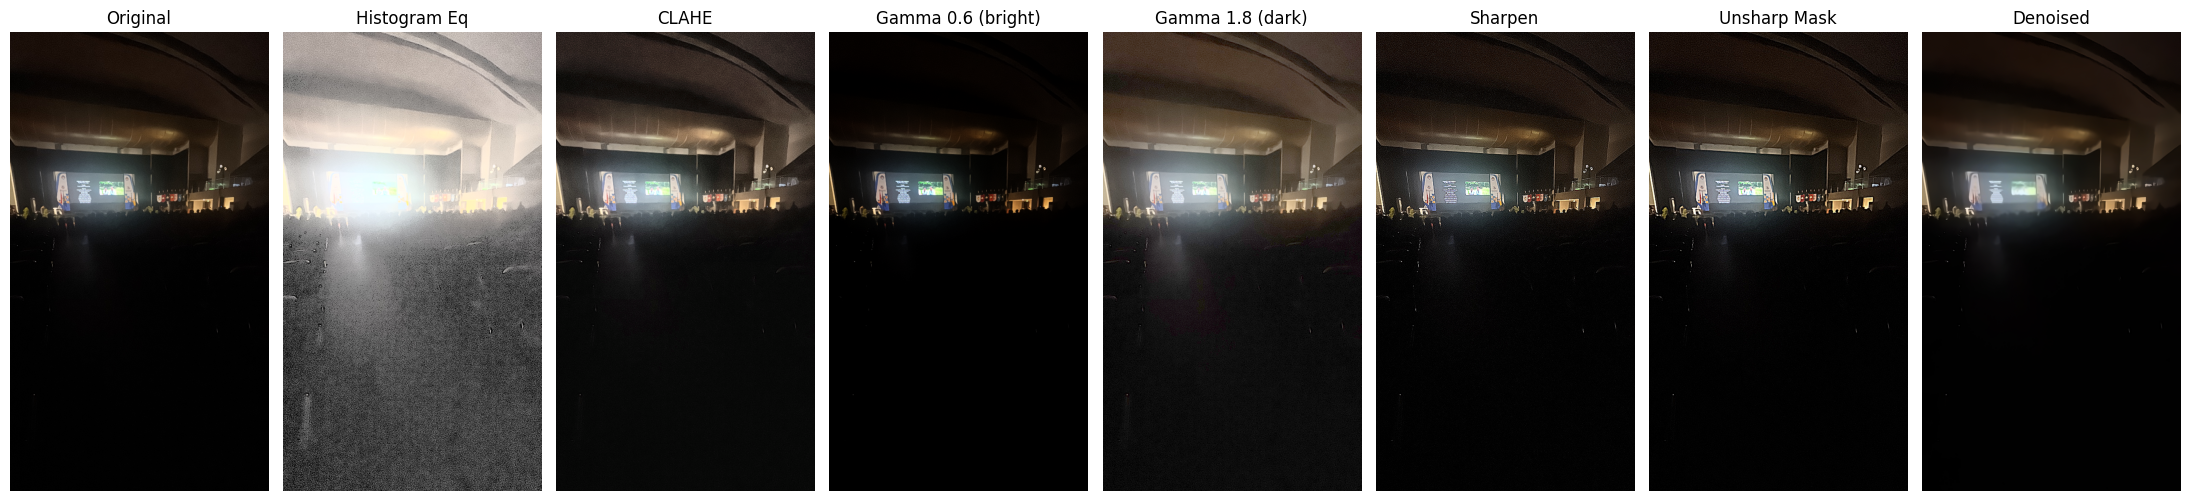

In [10]:
hist_eq   = histogram_equalization(img_rgb)
clahe_img = clahe_enhance(img_rgb, clip_limit=2.0)
bright    = gamma_correction(img_rgb, gamma=0.6)
dark      = gamma_correction(img_rgb, gamma=1.8)
sharp     = sharpen_image(img_rgb)
unsharp   = unsharp_mask(img_rgb, sigma=2.0, strength=1.5)
denoised  = denoise_image(img_rgb)

show_images(
    [img_rgb, hist_eq, clahe_img, bright, dark, sharp, unsharp, denoised],
    ['Original', 'Histogram Eq', 'CLAHE', 'Gamma 0.6 (bright)',
     'Gamma 1.8 (dark)', 'Sharpen', 'Unsharp Mask', 'Denoised'],
    figsize=(22, 6)
)

## Histogram Comparison

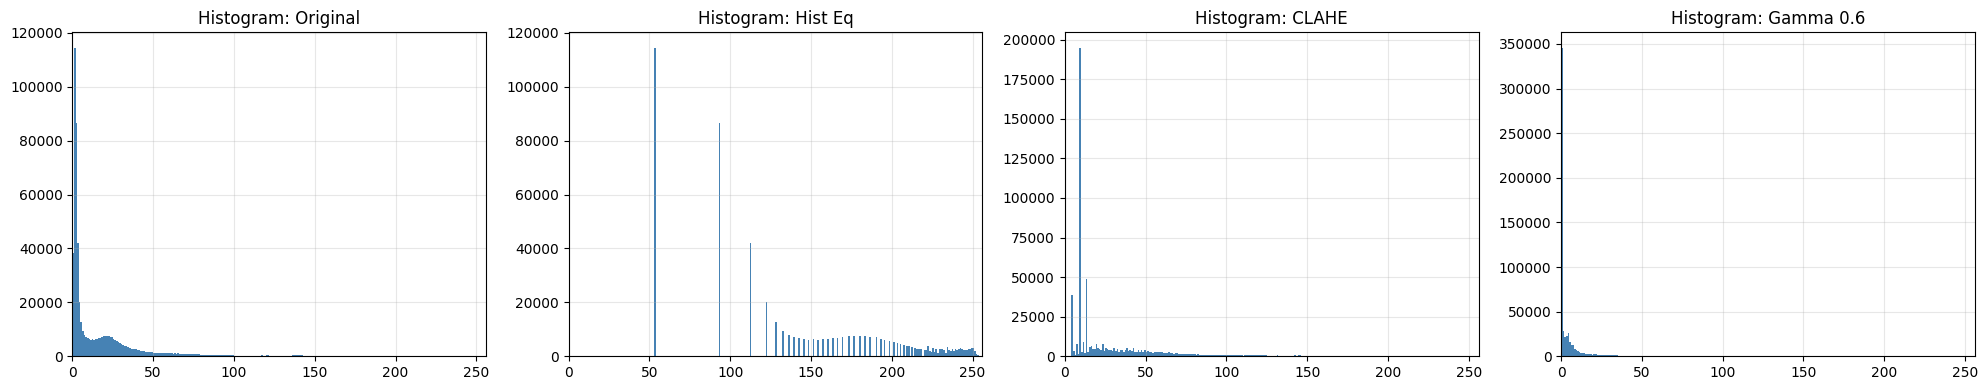

In [11]:
plot_histograms(
    [img_rgb, hist_eq, clahe_img, bright],
    ['Original', 'Hist Eq', 'CLAHE', 'Gamma 0.6'],
    figsize=(20, 4)
)

## Automatic Detection + Enhancement

Analyze brightness, contrast, and sharpness to choose the best technique.

In [12]:
def analyze_image(image):
    """Return image characteristics and label."""
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY) if image.ndim == 3 else image
    mean_brightness = float(np.mean(gray))
    std_contrast    = float(np.std(gray))
    lap_var         = float(cv2.Laplacian(gray, cv2.CV_64F).var())

    if mean_brightness < 70:
        label = 'Dark'
    elif mean_brightness > 180:
        label = 'Bright'
    elif std_contrast < 40:
        label = 'Low-contrast'
    elif lap_var < 100:
        label = 'Blurred'
    else:
        label = 'Normal'

    return {'brightness': mean_brightness,
            'contrast': std_contrast,
            'sharpness': lap_var,
            'label': label}


def auto_enhance(image):
    """Analyze then apply the most appropriate enhancement."""
    info = analyze_image(image)
    label = info['label']
    print(f"Detected: {label:<13} | "
          f"Brightness={info['brightness']:.1f}  "
          f"Contrast={info['contrast']:.1f}  "
          f"Sharpness={info['sharpness']:.1f}")

    if label == 'Dark':
        out = gamma_correction(image, gamma=0.5)
        out = clahe_enhance(out, clip_limit=2.0)
    elif label == 'Bright':
        out = gamma_correction(image, gamma=1.8)
    elif label == 'Low-contrast':
        out = clahe_enhance(image, clip_limit=3.0)
    elif label == 'Blurred':
        out = sharpen_image(image)
        out = clahe_enhance(out, clip_limit=2.0)
    else:
        out = image.copy()

    return out, label

Detected: Dark          | Brightness=19.0  Contrast=32.7  Sharpness=240.1


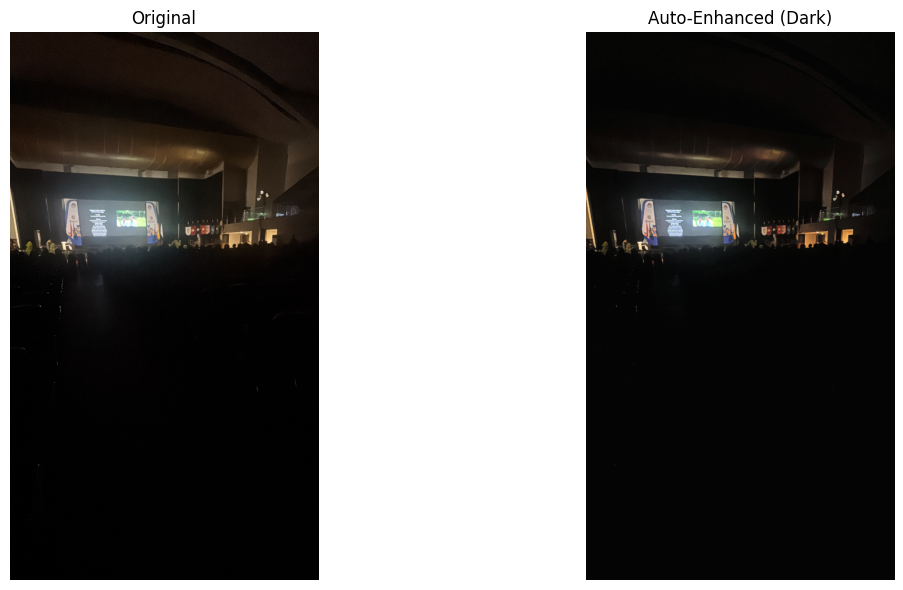

In [13]:
enhanced, detected_label = auto_enhance(img_rgb)

show_images(
    [img_rgb, enhanced],
    ['Original', f'Auto-Enhanced ({detected_label})'],
    figsize=(14, 6)
)

## Synthetic Degradation Tests

Simulate degraded images (dark, bright, blurry, low-contrast) and verify the auto pipeline fixes them.


=== Testing: DARK ===
Detected: Dark          | Brightness=5.3  Contrast=9.8  Sharpness=22.1


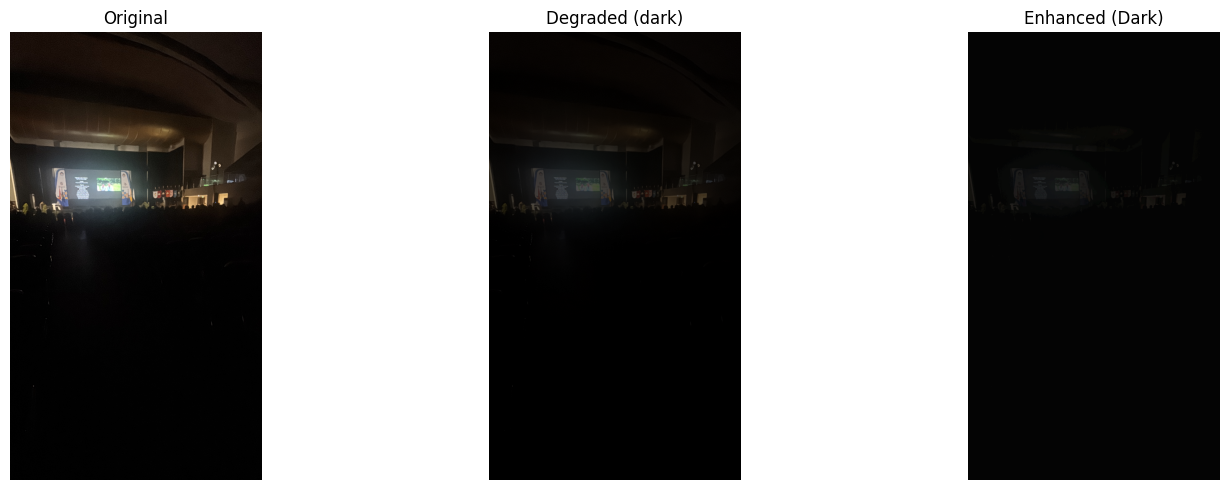


=== Testing: BRIGHT ===
Detected: Low-contrast  | Brightness=118.5  Contrast=29.9  Sharpness=174.7


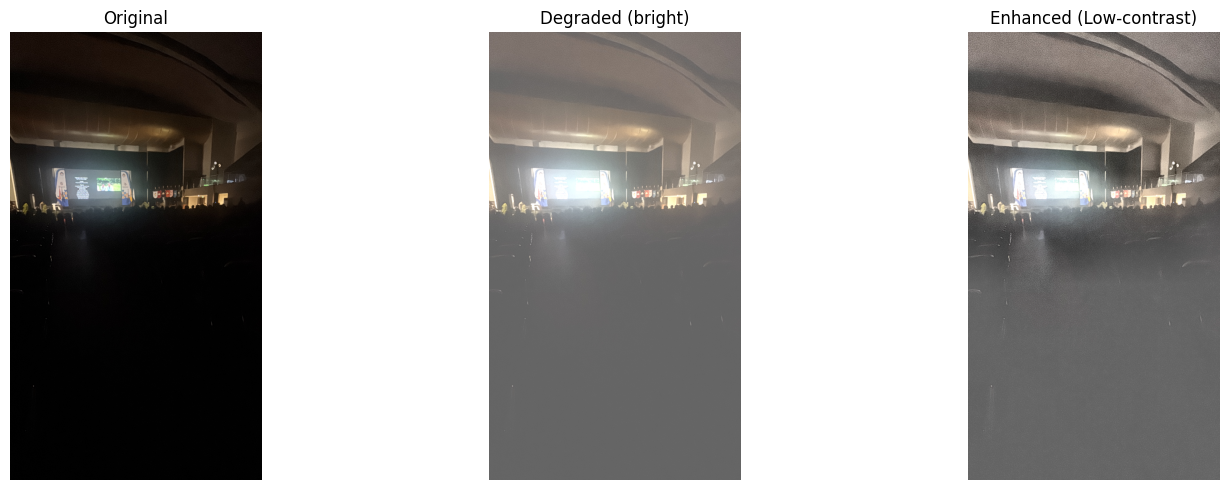


=== Testing: BLUR ===
Detected: Dark          | Brightness=19.0  Contrast=31.6  Sharpness=1.2


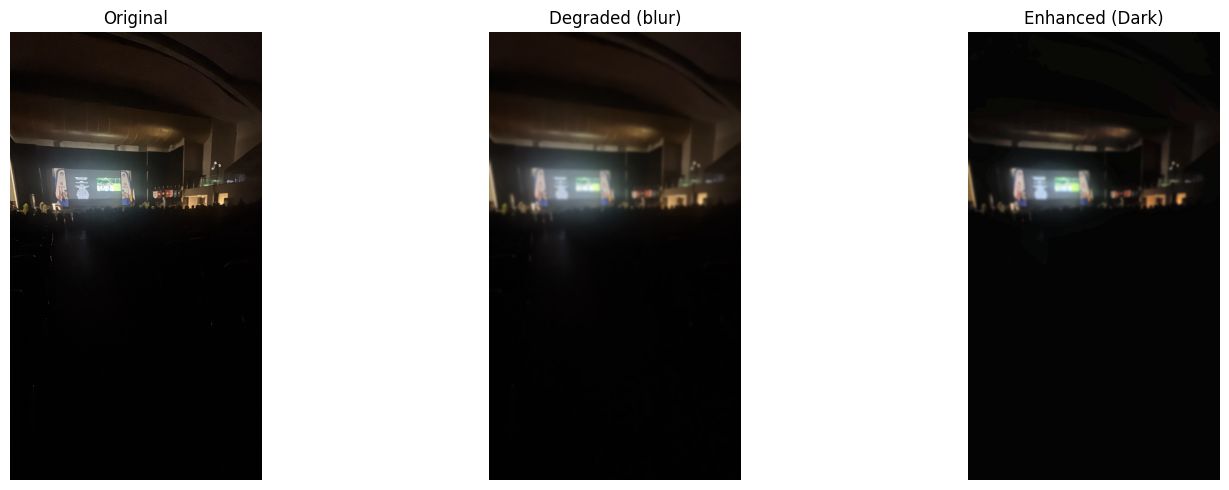


=== Testing: LOW_CONTRAST ===
Detected: Low-contrast  | Brightness=94.8  Contrast=9.9  Sharpness=23.9


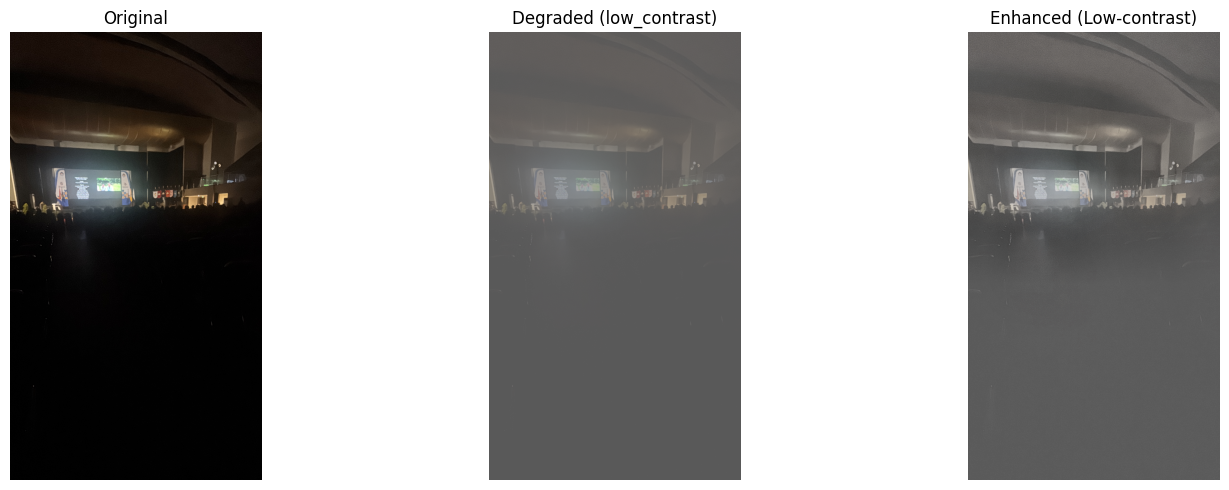


=== Testing: NOISY ===
Detected: Dark          | Brightness=24.8  Contrast=32.3  Sharpness=3206.0


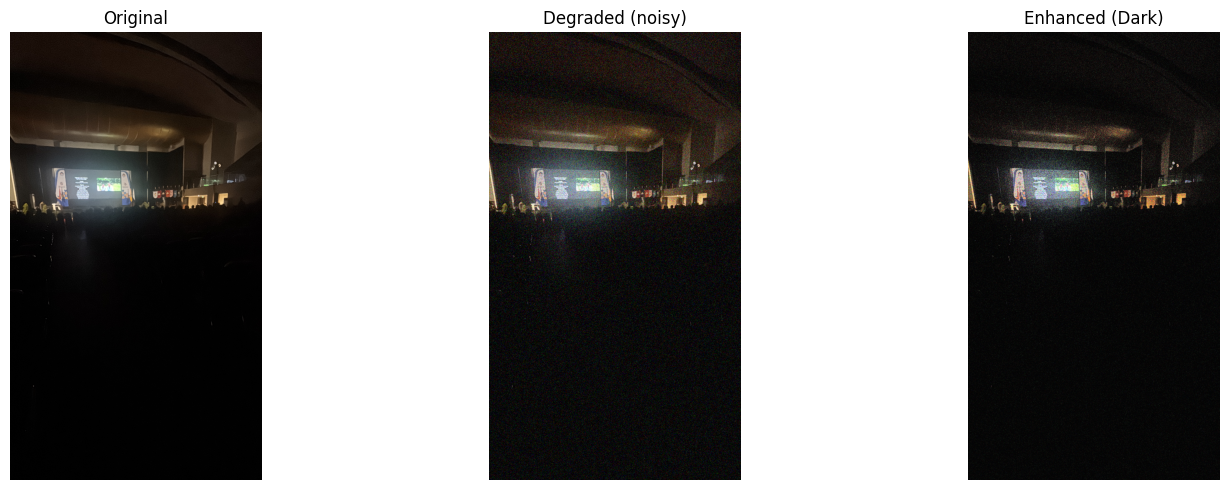

In [14]:
def degrade_image(image, mode='dark'):
    """Create synthetic degraded versions for testing."""
    if mode == 'dark':
        return (image * 0.3).astype(np.uint8)
    if mode == 'bright':
        return np.clip(image.astype(np.int16) + 100, 0, 255).astype(np.uint8)
    if mode == 'blur':
        return cv2.GaussianBlur(image, (15, 15), 0)
    if mode == 'low_contrast':
        return np.clip((image.astype(np.float32) - 128) * 0.3 + 128,
                       0, 255).astype(np.uint8)
    if mode == 'noisy':
        noise = np.random.normal(0, 25, image.shape).astype(np.float32)
        return np.clip(image + noise, 0, 255).astype(np.uint8)
    return image


for mode in ['dark', 'bright', 'blur', 'low_contrast', 'noisy']:
    print(f'\n=== Testing: {mode.upper()} ===')
    degraded = degrade_image(img_rgb, mode)
    enhanced, detected = auto_enhance(degraded)
    show_images(
        [img_rgb, degraded, enhanced],
        ['Original', f'Degraded ({mode})', f'Enhanced ({detected})'],
        figsize=(16, 5)
    )

## Save Results

In [16]:
# Save original and auto-enhanced outputs
base = filename.rsplit('.', 1)[0]

cv2.imwrite(f'{base}_enhanced.jpg',
            cv2.cvtColor(enhanced, cv2.COLOR_RGB2BGR))
cv2.imwrite(f'{base}_clahe.jpg',
            cv2.cvtColor(clahe_img, cv2.COLOR_RGB2BGR))
cv2.imwrite(f'{base}_sharp.jpg',
            cv2.cvtColor(unsharp, cv2.COLOR_RGB2BGR))
cv2.imwrite(f'{base}_denoised.jpg',
            cv2.cvtColor(denoised, cv2.COLOR_RGB2BGR))

# Download
files.download(f'{base}_enhanced.jpg')
files.download(f'{base}_clahe.jpg')
files.download(f'{base}_sharp.jpg')
files.download(f'{base}_denoised.jpg')

print('All results saved and downloaded.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All results saved and downloaded.
